In [1]:
import sys
sys.path.insert(0, '..')  # examples/, where utils.py lives

from utils import fix_pythonpath_if_working_locally
print('safetycage source:', fix_pythonpath_if_working_locally())


%load_ext autoreload
%autoreload 2

safetycage source: /Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src


In [2]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split

data = fetch_covtype(as_frame=True)
print(data.target_names)
print(data.feature_names)

x = data.data
# map target labels from 1-7 to 0-6
y = data.target - 1

# Split the dataset into two halves: one for the model, and one for the safety cage
x_model, x_cage, y_model, y_cage = train_test_split(x, y, test_size=0.5, random_state=42, stratify=y)

['Cover_Type']
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_0', 'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37', 'Soil_Type_38', 'Soil_Type_39']


In [3]:
# Split the model dataset into training, validation, and testing sets
x_model_train, x_model_val, y_model_train, y_model_val = train_test_split(x_model, y_model, test_size=0.2, random_state=42)
x_model_train, x_model_val, y_model_train, y_model_val = train_test_split(x_model_train, y_model_train, test_size=0.2, random_state=42)

In [79]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=10)

model.fit(x_model_train, y_model_train, eval_set=[(x_model_val, y_model_val)], verbose = False)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklear

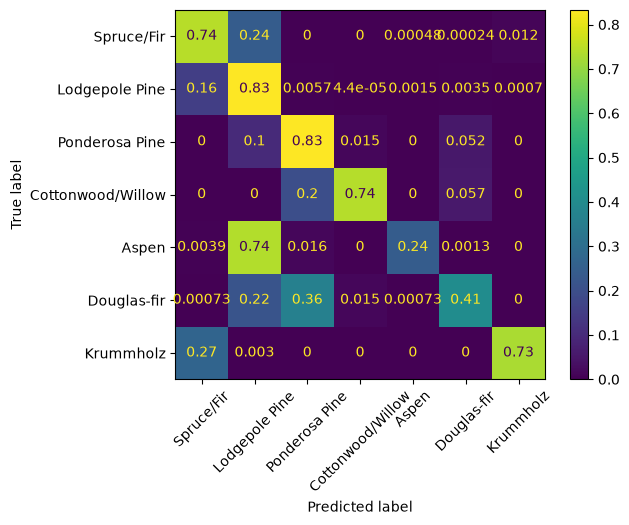

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

COVER_TYPES = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow",
    "Aspen", "Douglas-fir", "Krummholz",
]

y_pred_val = model.predict(x_model_val)

ConfusionMatrixDisplay.from_predictions(
    y_model_val, y_pred_val, display_labels=COVER_TYPES, xticks_rotation=45, normalize="true"
)
plt.show()

In [81]:
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score

y_proba_val = model.predict_proba(x_model_val)

y_pred_val = model.predict(x_model_val)
report = classification_report(y_model_val, y_pred_val, target_names=COVER_TYPES)
mcc = matthews_corrcoef(y_model_val, y_pred_val)
# roc_auc_score handles multiclass directly (one-vs-rest under the hood),
# no need to binarize y_model_val by hand.
macro_auc = roc_auc_score(y_model_val, y_proba_val, multi_class="ovr", average="macro")

print(report)
print(f"MCC:       {mcc:.3f}")
print(f"Macro AUC: {macro_auc:.3f}")

                   precision    recall  f1-score   support

       Spruce/Fir       0.76      0.74      0.75     16799
   Lodgepole Pine       0.78      0.83      0.81     22731
   Ponderosa Pine       0.78      0.83      0.81      2918
Cottonwood/Willow       0.74      0.74      0.74       244
            Aspen       0.81      0.24      0.37       762
      Douglas-fir       0.69      0.41      0.51      1375
        Krummholz       0.85      0.73      0.78      1652

         accuracy                           0.77     46481
        macro avg       0.77      0.65      0.68     46481
     weighted avg       0.77      0.77      0.77     46481

MCC:       0.632
Macro AUC: 0.960


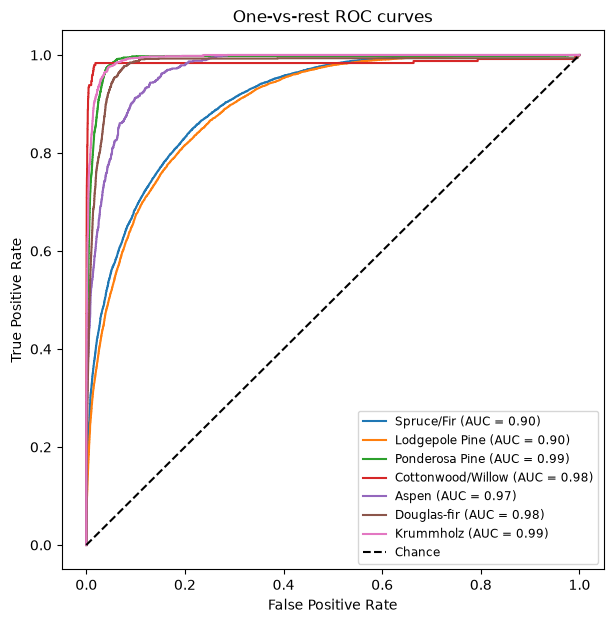

In [82]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba_val = model.predict_proba(x_model_val)
y_val_bin = label_binarize(y_model_val, classes=range(len(COVER_TYPES)))

fig, ax = plt.subplots(figsize=(7, 7))
for i, name in enumerate(COVER_TYPES):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_proba_val[:, i])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.2f})")

ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-rest ROC curves")
ax.legend(loc="lower right", fontsize="small")
plt.show()

In [83]:
# Split the model dataset into training, validation, and testing sets
x_cage_train, x_cage_test, y_cage_train, y_cage_test = train_test_split(x_cage, y_cage, test_size=0.2, random_state=42)
x_cage_train, x_cage_val, y_cage_train, y_cage_val = train_test_split(x_cage_train, y_cage_train, test_size=0.2, random_state=42)

incorrect_classifications_val = (y_pred_val!= y_model_val).to_numpy()

In [84]:
from safetycage.datamodules.array_datamodule import ArrayDataModule
data_module = ArrayDataModule(x_cage_train, y_cage_train, x_cage_val, y_cage_val, x_cage_test, y_cage_test)

In [85]:
from safetycage.modelmodules.sklearn_modelmodule import SklearnModelModule
model_module = SklearnModelModule(model)

In [86]:
from safetycage.methods.msp import MSP
from safetycage.methods.doctor import DOCTOR


msp = DOCTOR(model_module, data_module, method = "sum")
# msp = MSP(model_module, data_module)
msp.train_cage()

In [87]:
statistics_val = msp.predict(x_cage_val, y_cage_val)


In [88]:
from safetycage.utils.metrics import MCC, accuracy, recall, precision
metric = accuracy

result = msp.find_best_threshold(incorrect_classifications_val, statistics_val, metric_fn = metric)
result.keys()

dict_keys(['threshold_opt', 'metric_max', 'thresholds', 'metrics'])

In [89]:
result["threshold_opt"]
result["metric_max"]

array(0.77442396)

<Axes: xlabel='Decision threshold'>

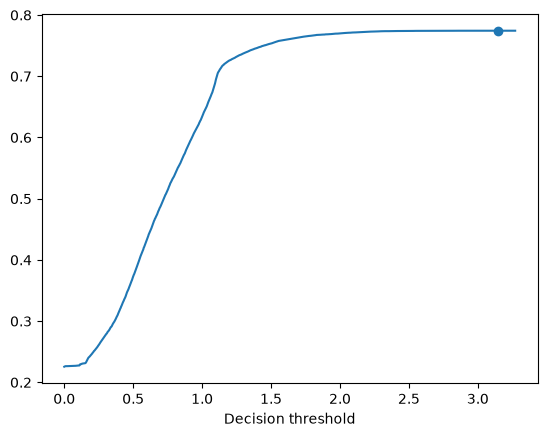

In [90]:
from safetycage.utils.visualise import plot_metric_vs_threshold

plot_metric_vs_threshold(result["thresholds"], result["metrics"])